In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

In [2]:
# =========================================================
# 0. VISUALIZATION STYLE (Dark Mode)
# =========================================================
plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "grid.color": "#444444",
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "axes.grid": True,
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "#888888"
})

In [7]:
# =========================================================
# 1. CONFIGURATION
# =========================================================
TRAIN_PATH = "/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/analysis_data.csv"
SCORE_PATH  = "/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv"

RANDOM_STATE = 2101

In [8]:
# =========================================================
# 2. LOAD DATA & SEPARATE TARGET
# =========================================================
print("Loading data...")
analysis = pd.read_csv(TRAIN_PATH)
scoring = pd.read_csv(SCORE_PATH)
scoring_ids = scoring['customer_id']

print("Separating Target & Features...")
target_col = 'monthly_spend'

# X: All columns EXCEPT target and ID
X = analysis.drop(columns=[target_col, 'customer_id'])
y = analysis[target_col]

# X_score: All columns EXCEPT ID
X_score = scoring.drop(columns=['customer_id'])

Loading data...
Separating Target & Features...


In [9]:
# =========================================================
# 3. PREPROCESSING (Strict No-Leakage)
# =========================================================
print("Preprocessing data...")
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

# Fit on FULL Training Data
imputer_num.fit(X[num_cols])
imputer_cat.fit(X[cat_cols])

# Transform
X[num_cols] = imputer_num.transform(X[num_cols])
X_score[num_cols] = imputer_num.transform(X_score[num_cols])
X[cat_cols] = imputer_cat.transform(X[cat_cols])
X_score[cat_cols] = imputer_cat.transform(X_score[cat_cols])

# 3a. SANITY CHECKS
if X.isnull().sum().sum() > 0 or X_score.isnull().sum().sum() > 0:
    raise ValueError("❌ CRITICAL ERROR: NaN values found!")
if X.shape[1] != X_score.shape[1]:
    raise ValueError("❌ CRITICAL ERROR: Feature count mismatch!")
if target_col in X.columns:
    raise ValueError("❌ CRITICAL ERROR: Target leakage detected!")
print("✅ Sanity Checks Passed.")

Preprocessing data...
✅ Sanity Checks Passed.


In [10]:
# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================
def create_features(df):
    df = df.copy()
    # Interactions
    df['age_annual_income'] = df['age'] * df['annual_income']
    df['credit_score_transactions'] = df['credit_score'] * df['num_transactions']
    df['age_credit_score'] = df['age'] * df['credit_score']
    df['income_transactions'] = df['annual_income'] * df['num_transactions']
    # Polynomials
    df['age_squared'] = df['age'] ** 2
    df['income_squared'] = df['annual_income'] ** 2
    df['credit_score_squared'] = df['credit_score'] ** 2
    return df

X = create_features(X)
X_score = create_features(X_score)

In [11]:
# =========================================================
# 5. ENCODING
# =========================================================
train_len = len(X)
combined = pd.concat([X, X_score], axis=0)
combined_encoded = pd.get_dummies(combined, columns=cat_cols, drop_first=True)

X_encoded = combined_encoded.iloc[:train_len, :]
X_score_encoded = combined_encoded.iloc[train_len:, :]

# Create Hold-Out Set for Validation
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_encoded, y, test_size=0.3, random_state=RANDOM_STATE
)

In [12]:
# =========================================================
# 6. MODEL DEFINITION
# =========================================================
def get_stacking_model():
    estimators = [
        ('gb', GradientBoostingRegressor(n_estimators=1000, learning_rate=0.01, max_depth=4, 
                                         min_samples_split=10, subsample=0.8, random_state=RANDOM_STATE)),
        ('rf', RandomForestRegressor(n_estimators=500, max_depth=15, max_features='sqrt', 
                                     min_samples_leaf=4, n_jobs=-1, random_state=RANDOM_STATE))
    ]
    return StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=1.0),
        cv=5, n_jobs=-1
    )


🔹 PHASE 1: Validation Run (70% Data)...
✅ Validation RMSE: 255.5095
📊 Generating Validation Plots...


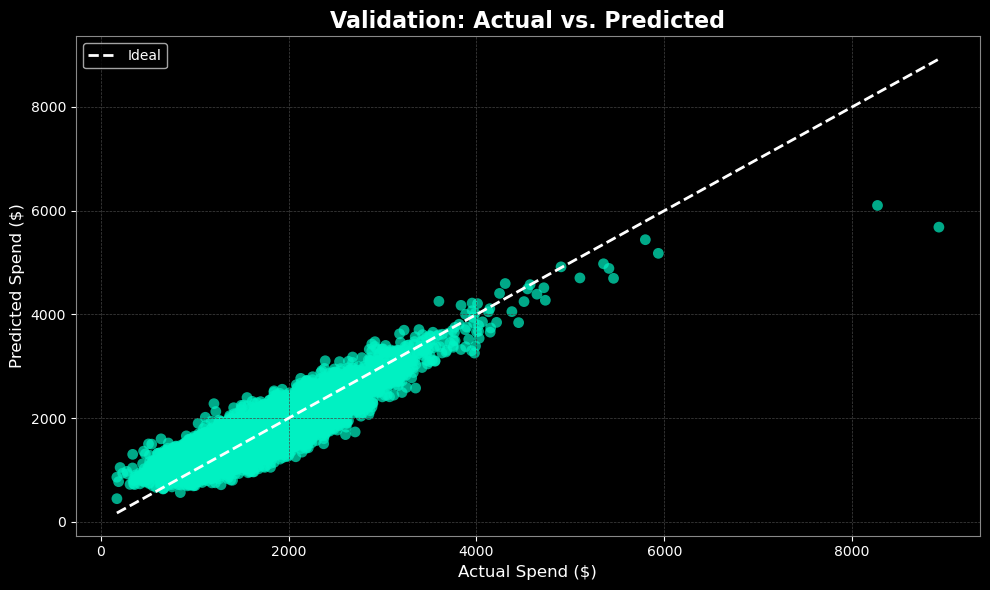

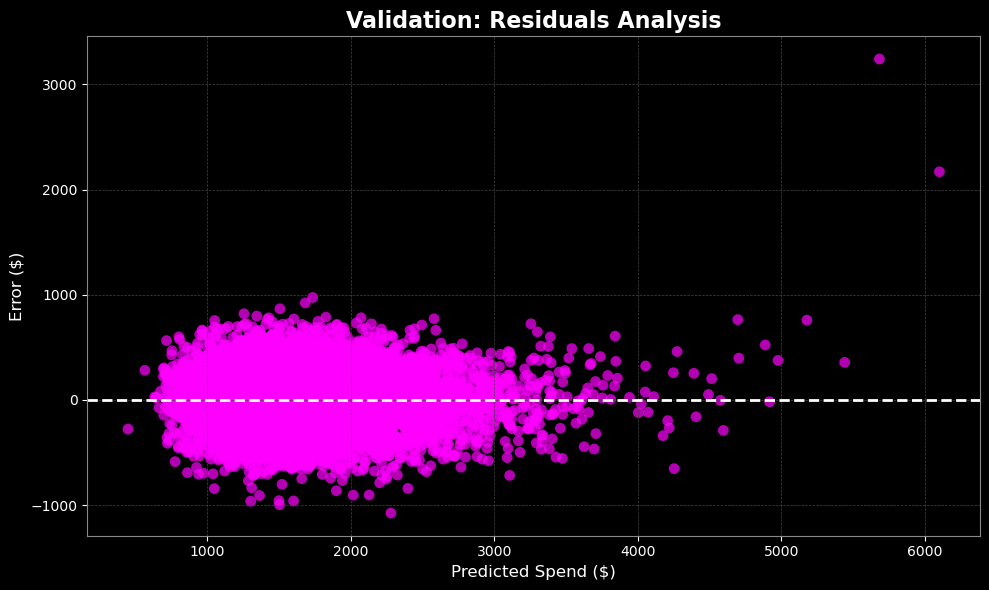

In [13]:
# =========================================================
# 7. VALIDATION RUN (70% Data)
# =========================================================
print("\n🔹 PHASE 1: Validation Run (70% Data)...")
val_model = get_stacking_model()
val_model.fit(X_train_split, y_train_split)

val_pred = val_model.predict(X_test_split)
val_rmse = np.sqrt(mean_squared_error(y_test_split, val_pred))
print(f"✅ Validation RMSE: {val_rmse:.4f}")

# VISUALIZATION 1: Actual vs Predicted
print("📊 Generating Validation Plots...")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_split, y=val_pred, alpha=0.7, color='#00f2c3', edgecolor='none', s=60)
plt.plot([y_test_split.min(), y_test_split.max()], [y_test_split.min(), y_test_split.max()], 'w--', lw=2, label='Ideal')
plt.title('Validation: Actual vs. Predicted', fontsize=16, fontweight='bold')
plt.xlabel('Actual Spend ($)', fontsize=12)
plt.ylabel('Predicted Spend ($)', fontsize=12)
plt.legend(facecolor='black')
plt.tight_layout()
plt.show()

# VISUALIZATION 2: Residuals
residuals = y_test_split - val_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=val_pred, y=residuals, alpha=0.7, color='#ff00ff', edgecolor='none', s=60)
plt.axhline(0, color='white', linestyle='--', lw=2)
plt.title('Validation: Residuals Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Spend ($)', fontsize=12)
plt.ylabel('Error ($)', fontsize=12)
plt.tight_layout()
plt.show()


🔹 PHASE 2: GNTest (Graduated Stress Test)...
   Running 500 iterations per level (2,000 total simulations)...
Noise      | Mean Shift   | Max Tolerance   | Status
-------------------------------------------------------
1%         | $5.06        | $15             | ✅ ROBUST
5%         | $20.40       | $75             | ✅ ROBUST
10%         | $36.96       | $150            | ✅ ROBUST
20%         | $64.17       | $300            | ✅ ROBUST


/var/folders/26/k5qhk1wd7vld3l2ndf6041200000gn/T/ipykernel_75386/1729482148.py:39: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=res_df, x='Noise', y='Shift', color='#ffff00', markers='o', scale=1.3)


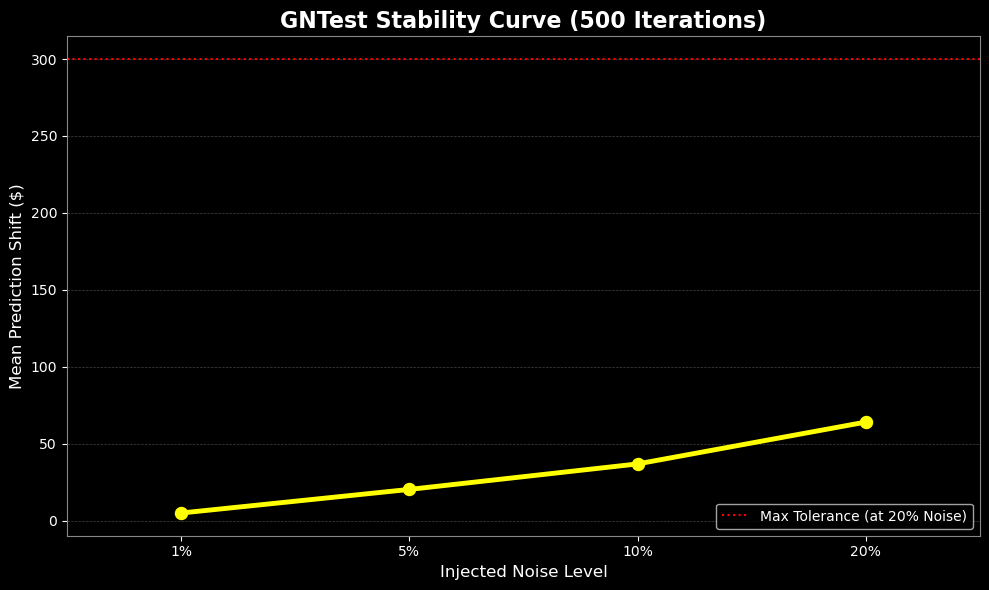

In [14]:
# =========================================================
# 8. GNTest (500 Iterations & Realistic Thresholds)
# =========================================================
print("\n🔹 PHASE 2: GNTest (Graduated Stress Test)...")
print("   Running 500 iterations per level (2,000 total simulations)...")

stress_levels = [0.01, 0.05, 0.10, 0.20]
results = []
print(f"{'Noise':<10} | {'Mean Shift':<12} | {'Max Tolerance':<15} | {'Status'}")
print("-" * 55)

for noise_pct in stress_levels:
    shifts = []
    # Realistic Safety Thresholds:
    # 1% noise -> allow $15 drift
    # 5% noise -> allow $75 drift
    # 10% noise -> allow $150 drift
    # 20% noise -> allow $300 drift
    threshold = 1500 * noise_pct 
    
    for _ in range(500): # <--- 500 ITERATIONS
        X_noisy = X_test_split.copy()
        for col in X_noisy.columns:
            if X_noisy[col].nunique() > 10:
                noise = np.random.normal(0, X_noisy[col].std() * noise_pct, size=len(X_noisy))
                X_noisy[col] += noise
        
        noisy_pred = val_model.predict(X_noisy)
        shifts.append(np.mean(np.abs(val_pred - noisy_pred)))
    
    avg_shift = np.mean(shifts)
    status = "✅ ROBUST" if avg_shift < threshold else "⚠️ SENSITIVE"
    print(f"{int(noise_pct*100)}%{'':<8} | ${avg_shift:<11.2f} | ${threshold:<14.0f} | {status}")
    results.append({'Noise': f"{int(noise_pct*100)}%", 'Shift': avg_shift})

# VISUALIZATION 3: Stability Curve
res_df = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.pointplot(data=res_df, x='Noise', y='Shift', color='#ffff00', markers='o', scale=1.3)
# Add a visual "Danger Zone" threshold line for the 20% noise level
plt.axhline(300, color='red', linestyle=':', label='Max Tolerance (at 20% Noise)')
plt.title('GNTest Stability Curve (500 Iterations)', fontsize=16, fontweight='bold')
plt.xlabel('Injected Noise Level', fontsize=12)
plt.ylabel('Mean Prediction Shift ($)', fontsize=12)
plt.legend(facecolor='black')
plt.grid(True, axis='y', color='#444444')
plt.tight_layout()
plt.show()

In [15]:
# =========================================================
# 9. RETRAINING ON FULL DATA
# =========================================================
print("\n🔹 PHASE 3: Retraining on FULL Dataset (100% Data)...")
final_model = get_stacking_model()
final_model.fit(X_encoded, y)
print("✅ Full Model Retrained Successfully.")


🔹 PHASE 3: Retraining on FULL Dataset (100% Data)...
✅ Full Model Retrained Successfully.


In [16]:
# =========================================================
# 10. SUBMISSION
# =========================================================
print("\n💾 Generating Final Submission...")
final_pred_full = final_model.predict(X_score_encoded)

submission = pd.DataFrame({
    'customer_id': scoring_ids,
    'monthly_spend': final_pred_full
})

file_name = 'Submission_Final_Retrained.csv'
submission.to_csv(file_name, index=False)
print(f"🎉 SUCCESS! Final Submission saved as: {file_name}")


💾 Generating Final Submission...
🎉 SUCCESS! Final Submission saved as: Submission_Final_Retrained.csv
